# Transformer-Based Music Identification: FMA Dataset Exploration

**CS7150 Final Project — Edwin Yu, Aaron Gordoa, Aritra Saharay**

This notebook serves as the data exploration and preprocessing pipeline for our
transformer-based music identification project. We use the
[Free Music Archive (FMA)](https://github.com/mdeff/fma) dataset
(Defferrard et al., 2017) as our primary audio corpus.

**Goals of this notebook:**
1. Download and load FMA metadata and a subset of audio tracks.
2. Explore dataset statistics: genre distribution, duration, feature space.
3. Build a spectrogram extraction pipeline (mel spectrograms) suitable for
   transformer input.
4. Implement audio augmentation strategies (noise injection, pitch shifting,
   time stretching, filtering) motivated by contrastive learning literature
   (Chang et al., 2020; Singh et al., 2025).
5. Demonstrate contrastive pair construction for training a neural audio
   fingerprinting model.

**References:**
- FMA Dataset: [arXiv:1612.01840](https://arxiv.org/abs/1612.01840)
- NAFP (Contrastive Audio Fingerprinting): [arXiv:2010.11910](https://arxiv.org/abs/2010.11910)
- Robust Neural AFP with Foundation Models: [arXiv:2511.05399](https://arxiv.org/abs/2511.05399)
- Contrastive & Transfer Learning for AFP: [arXiv:2507.06070](https://arxiv.org/abs/2507.06070)

## 1. Environment Setup & Dependencies

In [ ]:
# ---------------------------------------------------------------------------
# Install required packages. Colab has numpy, pandas, matplotlib pre-installed
# but we need librosa for audio processing and torchaudio for augmentations.
# ---------------------------------------------------------------------------
!pip install -q librosa soundfile torchaudio

In [1]:
import os
import ast
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import torch
import torchaudio
import torchaudio.transforms as T
import IPython.display as ipd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Reproducibility seed for all random operations in the notebook.
# ---------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"librosa  : {librosa.__version__}")
print(f"torch    : {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")

librosa  : 0.11.0
torch    : 2.5.1
torchaudio: 2.5.1


## 2. Download the FMA Dataset

We download two components:
- **`fma_metadata.zip`** (342 MiB): contains `tracks.csv`, `genres.csv`,
  `features.csv`, and `echonest.csv` with pre-computed librosa features
  and metadata for all 106,574 tracks.
- **`fma_small.zip`** (7.2 GiB): 8,000 tracks of 30 seconds each, balanced
  across 8 top-level genres. This is the GTZAN-comparable subset and is
  small enough to fit in a Colab runtime disk.

If the audio subset is too large for your Colab tier, you can skip the
`fma_small` download and work purely with the pre-computed features in
Section 3. The spectrogram and augmentation sections (4–6) require audio.

In [2]:
# ---------------------------------------------------------------------------
# Base URL for the FMA dataset hosted by the Swiss Data Science Center.
# ---------------------------------------------------------------------------
FMA_BASE_URL = "https://os.unil.cloud.switch.ch/fma"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Download and extract metadata (always needed).
# ---------------------------------------------------------------------------
if not (DATA_DIR / "fma_metadata").exists():
    print("Downloading fma_metadata.zip (~342 MiB)...")
    !curl -L -o {DATA_DIR}/fma_metadata.zip {FMA_BASE_URL}/fma_metadata.zip
    !cd {DATA_DIR} && unzip -q -o fma_metadata.zip
    print("Metadata extracted.")
else:
    print("Metadata already present.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  341M  100  341M    0     0  12.4M      0  0:00:27  0:00:27 --:--:-- 13.9M
Metadata extracted.


In [3]:
# ---------------------------------------------------------------------------
# Download and extract audio (fma_small). Set DOWNLOAD_AUDIO = False to skip.
# On free Colab (~78 GB disk), this should fit comfortably.
# ---------------------------------------------------------------------------
DOWNLOAD_AUDIO = True  # <-- Set to False if you only want metadata/features

AUDIO_DIR = DATA_DIR / "fma_small"

if DOWNLOAD_AUDIO and not AUDIO_DIR.exists():
    print("Downloading fma_small.zip (~7.2 GiB) — this will take a few minutes...")
    !curl -L -o {DATA_DIR}/fma_small.zip {FMA_BASE_URL}/fma_small.zip
    !cd {DATA_DIR} && unzip -q -o fma_small.zip
    print("Audio extracted.")
elif AUDIO_DIR.exists():
    print("Audio already present.")
else:
    print("Audio download skipped. Sections 4-6 will not run.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7323M  100 7323M    0     0  13.4M      0  0:09:04  0:09:04 --:--:-- 16.9M     0  12.0M      0  0:10:07  0:00:21  0:09:46 13.4M9964k9:12  0:01:22  0:07:50 15.4M   0  13.3M      0  0:09:07  0:01:26  0:07:41 15.8M0  0:09:03  0:01:29  0:07:34 16.5M 13.7M      0  0:08:52  0:01:40  0:07:12 15.7M:01:49  0:06:54 16.6M13.9M      0  0:08:43  0:02:00  0:06:43 13.4M2M:05:01 17.2M8:50  0:05:35  0:03:15 14.7M     0  0:09:03  0:07:05  0:01:58 16.5M:01:06 14.5M07  0:08:04  0:01:03 14.8M  0:08:13  0:00:53 12.0M5.3M
Audio extracted.


## 3. Metadata & Feature Exploration

The FMA metadata CSV files use a multi-level column index. We load them
with the utility functions from the FMA repository, adapted here inline
so the notebook is self-contained.

In [6]:
def load_tracks(filepath: str) -> pd.DataFrame:
    """
    Load the FMA tracks.csv into a DataFrame with a proper MultiIndex on
    columns and typed columns (dates parsed, genres as lists, etc.).

    This is adapted from the official FMA utils.load() to be self-contained.

    Args:
        filepath: Path to tracks.csv.

    Returns:
        A pandas DataFrame indexed by track_id with MultiIndex columns.
    """
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])

    # ---------- Type conversions ----------
    COLUMNS = [
        ("track", "tags"),
        ("track", "genres"),
        ("track", "genres_all"),
    ]
    for col in COLUMNS:
        tracks[col] = tracks[col].map(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

    COLUMNS = [
        ("track", "date_created"),
        ("track", "date_recorded"),
        ("album", "date_created"),
        ("album", "date_released"),
        ("artist", "date_created"),
        ("artist", "active_year_begin"),
        ("artist", "active_year_end"),
    ]
    for col in COLUMNS:
        tracks[col] = pd.to_datetime(tracks[col], errors="coerce")

    SUBSETS = ("small", "medium", "large")
    tracks["set", "subset"] = tracks["set", "subset"].astype(
        pd.CategoricalDtype(categories=SUBSETS, ordered=True)
    )
    SPLITS = ("training", "validation", "test")
    tracks["set", "split"] = tracks["set", "split"].astype(
        pd.CategoricalDtype(categories=SPLITS, ordered=True)
    )

    return tracks


# ---------------------------------------------------------------------------
# Load all metadata tables.
# ---------------------------------------------------------------------------
METADATA_DIR = DATA_DIR / "fma_metadata"

tracks = load_tracks(str(METADATA_DIR / "tracks.csv"))
genres = pd.read_csv(METADATA_DIR / "genres.csv", index_col=0)
features = pd.read_csv(METADATA_DIR / "features.csv", index_col=0, header=[0, 1, 2])

print(f"tracks   : {tracks.shape}")
print(f"genres   : {genres.shape}")
print(f"features : {features.shape}")

tracks   : (106574, 52)
genres   : (163, 4)
features : (106574, 518)


In [7]:
# ---------------------------------------------------------------------------
# Filter to the 'small' subset (8,000 tracks, 8 balanced genres) which is
# what we have audio for and what mirrors the classic GTZAN benchmark.
# ---------------------------------------------------------------------------
small_mask = tracks["set", "subset"] <= "small"
tracks_small = tracks[small_mask]

print(f"Tracks in 'small' subset: {len(tracks_small)}")
print(f"Genres: {sorted(tracks_small['track', 'genre_top'].dropna().unique())}")
print(f"\nSplit distribution:")
print(tracks_small["set", "split"].value_counts())

Tracks in 'small' subset: 8000
Genres: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

Split distribution:
training      6400
validation     800
test           800
Name: (set, split), dtype: int64


### 3.1 Genre Distribution

The `fma_small` subset is designed to be genre-balanced. Let's verify this
and understand what we're working with. For audio fingerprinting, genre
diversity matters because the model needs to generalize across very different
spectral characteristics (e.g., electronic vs. classical vs. hip-hop).

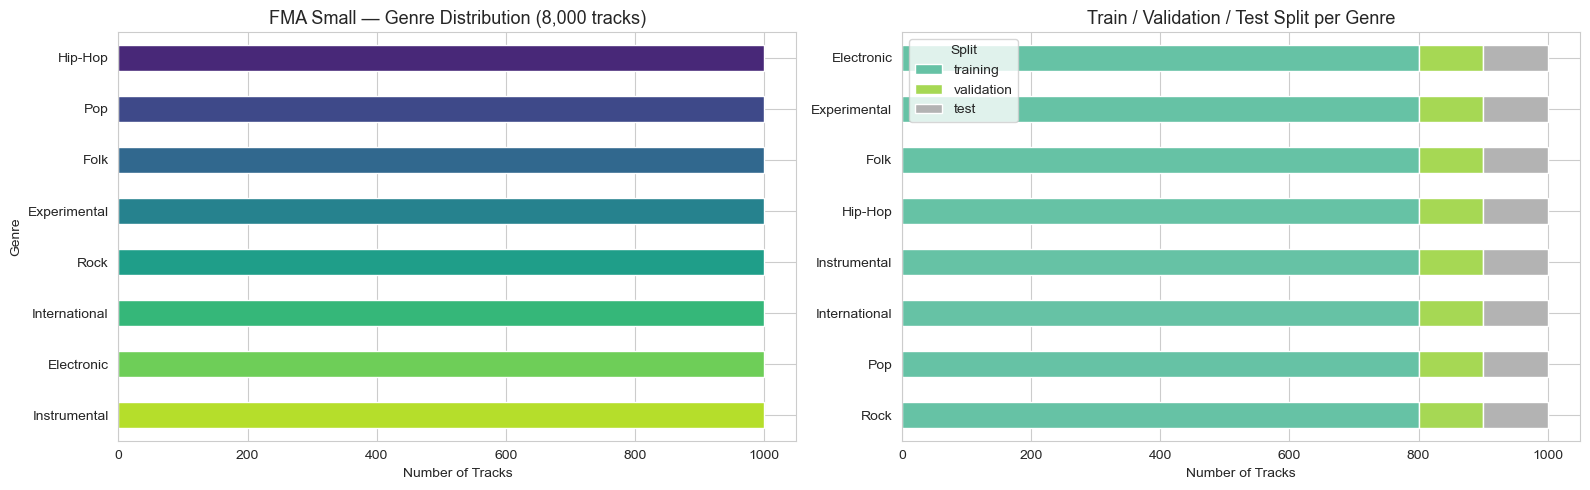

In [8]:
genre_counts = tracks_small["track", "genre_top"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Bar chart of genre distribution ---
palette = sns.color_palette("viridis", n_colors=len(genre_counts))
genre_counts.plot.barh(ax=axes[0], color=palette)
axes[0].set_title("FMA Small — Genre Distribution (8,000 tracks)", fontsize=13)
axes[0].set_xlabel("Number of Tracks")
axes[0].set_ylabel("Genre")
axes[0].invert_yaxis()

# --- Split distribution per genre ---
split_genre = tracks_small.groupby(
    [("track", "genre_top"), ("set", "split")]
).size().unstack(fill_value=0)
split_genre.plot.barh(stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Train / Validation / Test Split per Genre", fontsize=13)
axes[1].set_xlabel("Number of Tracks")
axes[1].set_ylabel("")
axes[1].invert_yaxis()
axes[1].legend(title="Split")

plt.tight_layout()
plt.show()

### 3.2 Pre-computed Feature Space (MFCC)

The FMA metadata includes pre-computed features via librosa: MFCCs,
chroma, spectral contrast, tonnetz, etc. Let's do a quick PCA projection
of the MFCC features to see how well genres separate in feature space.
This gives us a baseline sense of the discriminability of spectral features
before we even touch the transformer.

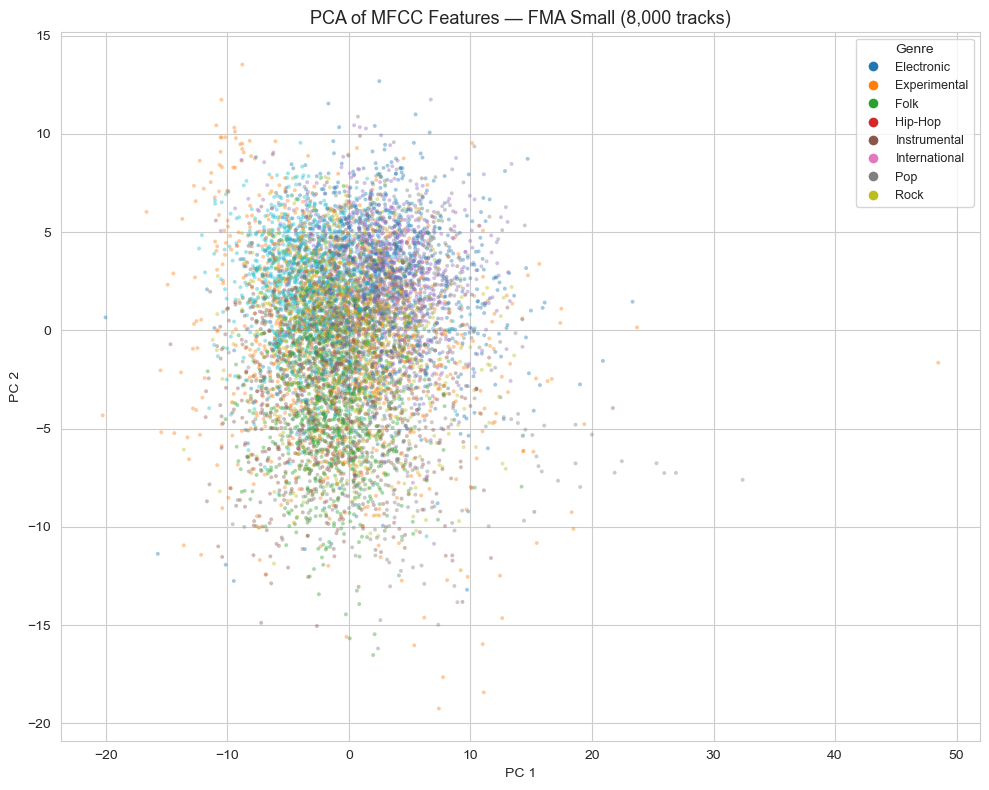

Note: Significant genre overlap in 2D PCA is expected — MFCCs alone
are insufficient for fine-grained discrimination. This motivates the
use of learned representations via transformer encoders.


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------------------------------------------------------------------
# Extract MFCC features for the small subset and project to 2D with PCA.
# ---------------------------------------------------------------------------
features_small = features.loc[tracks_small.index]
X_mfcc = features_small["mfcc"].dropna()

# Align indices: only keep tracks that have both features and a genre label.
valid_idx = X_mfcc.index.intersection(
    tracks_small[tracks_small["track", "genre_top"].notna()].index
)
X_mfcc = X_mfcc.loc[valid_idx]
y_genre = tracks_small.loc[valid_idx, ("track", "genre_top")]

# Standardize, then PCA to 2D.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mfcc)
X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

le = LabelEncoder()
y_encoded = le.fit_transform(y_genre)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_encoded, cmap="tab10", alpha=0.4, s=8, edgecolors="none"
)
# Build a legend from the label encoder classes.
handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=plt.cm.tab10(i / len(le.classes_)),
               markersize=8, label=g)
    for i, g in enumerate(le.classes_)
]
ax.legend(handles=handles, title="Genre", loc="upper right", fontsize=9)
ax.set_title("PCA of MFCC Features — FMA Small (8,000 tracks)", fontsize=13)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()

print(
    f"Note: Significant genre overlap in 2D PCA is expected — MFCCs alone\n"
    f"are insufficient for fine-grained discrimination. This motivates the\n"
    f"use of learned representations via transformer encoders."
)

### 3.3 Track Duration & Sampling Rate Statistics

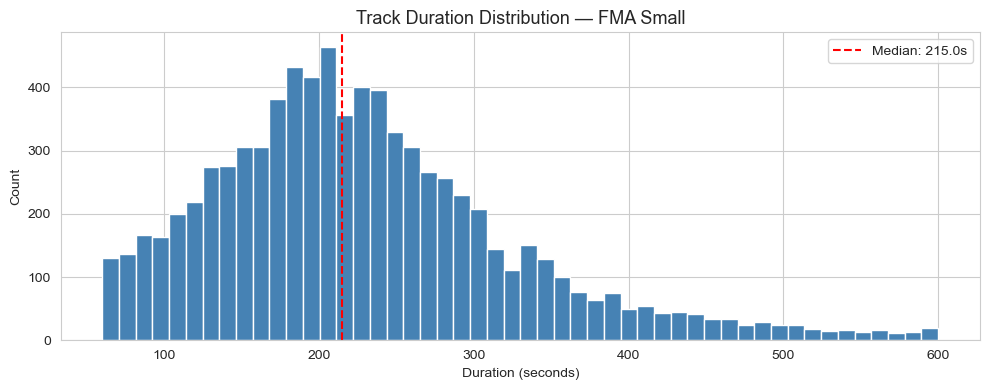

Duration stats:
count    8000.000000
mean      228.841500
std        98.394854
min        60.000000
25%       161.000000
50%       215.000000
75%       279.000000
max       600.000000
Name: (track, duration), dtype: float64


In [10]:
durations = tracks_small["track", "duration"]

fig, ax = plt.subplots(figsize=(10, 4))
durations.hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(durations.median(), color="red", linestyle="--", label=f"Median: {durations.median():.1f}s")
ax.set_title("Track Duration Distribution — FMA Small", fontsize=13)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Duration stats:")
print(durations.describe())

## 4. Audio Loading & Spectrogram Pipeline

For a transformer-based audio fingerprinting system, the standard input
representation is a **mel spectrogram** — a time-frequency representation
that compresses the frequency axis onto the mel scale (closer to human
auditory perception).

Following the conventions in NAFP (Chang et al., 2020) and the foundation
model fingerprinting paper (Singh et al., 2025), we use:
- Sample rate: 16,000 Hz (downsampled from the original)
- FFT window: 1024 samples (~64 ms)
- Hop length: 256 samples (~16 ms)
- Mel bands: 128
- Log-scale amplitude (dB)

In [11]:
# ---------------------------------------------------------------------------
# Spectrogram extraction configuration. These parameters follow conventions
# from NAFP and recent neural audio fingerprinting literature.
# ---------------------------------------------------------------------------
SAMPLE_RATE: int = 16_000      # Target sample rate (Hz)
N_FFT: int = 1024              # FFT window size
HOP_LENGTH: int = 256          # Hop length between FFT windows
N_MELS: int = 128              # Number of mel frequency bands
SEGMENT_DURATION: float = 3.0  # Duration of each audio segment (seconds)
SEGMENT_SAMPLES: int = int(SEGMENT_DURATION * SAMPLE_RATE)  # 48,000 samples


def get_audio_path(audio_dir: Path, track_id: int) -> Path:
    """
    Construct the filesystem path for a given FMA track ID.

    The FMA dataset organizes audio files into subdirectories based on the
    first three digits of the zero-padded 6-digit track ID. For example,
    track 2 is at 000/000002.mp3 and track 12345 is at 012/012345.mp3.

    Args:
        audio_dir: Root directory of the FMA audio files.
        track_id:  Integer track ID.

    Returns:
        Path object pointing to the .mp3 file.
    """
    tid_str = f"{track_id:06d}"
    return audio_dir / tid_str[:3] / f"{tid_str}.mp3"


def load_audio(
    filepath: Path,
    sr: int = SAMPLE_RATE,
    mono: bool = True,
) -> Optional[np.ndarray]:
    """
    Load an audio file, resample to the target sample rate, and convert
    to mono.

    Args:
        filepath: Path to the audio file.
        sr:       Target sample rate.
        mono:     Whether to convert to mono.

    Returns:
        1-D numpy array of audio samples, or None if loading fails.
    """
    try:
        y, _ = librosa.load(str(filepath), sr=sr, mono=mono)
        return y
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None


def compute_mel_spectrogram(
    y: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    n_mels: int = N_MELS,
) -> np.ndarray:
    """
    Compute a log-scaled mel spectrogram from a raw audio waveform.

    The output is in decibel scale (dB) with peak normalization, which is
    the standard input format for neural audio fingerprinting models.

    Args:
        y:          1-D audio waveform array.
        sr:         Sample rate of the waveform.
        n_fft:      FFT window size.
        hop_length: Number of samples between successive FFT frames.
        n_mels:     Number of mel frequency bands.

    Returns:
        2-D numpy array of shape (n_mels, time_frames) in dB scale.
    """
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

In [ ]:
# ---------------------------------------------------------------------------
# Load a few sample tracks (one per genre) and visualize their spectrograms.
# This demonstrates the raw input our transformer will consume.
# ---------------------------------------------------------------------------
if AUDIO_DIR.exists():
    # Pick one random track from each genre for visualization.
    sample_tracks = (
        tracks_small
        .groupby(("track", "genre_top"))
        .apply(lambda g: g.sample(1, random_state=SEED))
        .droplevel(0)
    )

    n_genres = len(sample_tracks)
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    for i, (track_id, row) in enumerate(sample_tracks.iterrows()):
        genre = row[("track", "genre_top")]
        fpath = get_audio_path(AUDIO_DIR, track_id)

        y = load_audio(fpath)
        if y is None:
            axes[i].set_title(f"{genre} (load error)")
            continue

        S_dB = compute_mel_spectrogram(y)
        librosa.display.specshow(
            S_dB, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis="time", y_axis="mel", ax=axes[i], cmap="magma"
        )
        axes[i].set_title(f"{genre} (ID: {track_id})", fontsize=11)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    fig.suptitle(
        "Mel Spectrograms — One Sample per Genre (FMA Small)",
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.show()
else:
    print("Audio not downloaded — skipping spectrogram visualization.")

## 5. Audio Augmentation Pipeline for Contrastive Learning

The core idea behind neural audio fingerprinting (NAFP, GraFPrint, and
the foundation model approach) is **contrastive learning**: the model
learns to produce similar embeddings for different distorted versions of
the same track, and dissimilar embeddings for different tracks.

Following the augmentation strategies from the literature, we implement:
1. **Additive Gaussian noise** — simulates ambient noise in real-world
   recording scenarios.
2. **Time stretching** — the audio is sped up or slowed down without
   changing pitch (common on TikTok/social media).
3. **Pitch shifting** — the pitch is raised or lowered without changing
   speed.
4. **Low-pass / high-pass filtering** — simulates the frequency response
   of cheap speakers or phone microphones. (Highlighted as critical by
   the 2507.06070 paper.)
5. **Random gain** — simulates volume differences between recordings.

In [12]:
import scipy.signal


def augment_add_noise(
    y: np.ndarray,
    snr_db: float = 20.0,
) -> np.ndarray:
    """
    Add Gaussian white noise at a specified signal-to-noise ratio (SNR).

    Args:
        y:      1-D audio waveform.
        snr_db: Target SNR in decibels. Lower values = more noise.

    Returns:
        Noisy audio waveform (same shape as input).
    """
    signal_power = np.mean(y ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), y.shape)
    return (y + noise).astype(np.float32)


def augment_time_stretch(
    y: np.ndarray,
    rate: float = 1.1,
) -> np.ndarray:
    """
    Time-stretch the audio by the given rate without changing pitch.

    A rate > 1 speeds up the audio; rate < 1 slows it down.

    Args:
        y:    1-D audio waveform.
        rate: Stretch factor.

    Returns:
        Time-stretched waveform.
    """
    return librosa.effects.time_stretch(y, rate=rate)


def augment_pitch_shift(
    y: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_steps: float = 2.0,
) -> np.ndarray:
    """
    Shift the pitch of the audio by a given number of semitones.

    Args:
        y:       1-D audio waveform.
        sr:      Sample rate.
        n_steps: Number of semitones to shift (positive = up, negative = down).

    Returns:
        Pitch-shifted waveform.
    """
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


def augment_lowpass(
    y: np.ndarray,
    sr: int = SAMPLE_RATE,
    cutoff_hz: float = 4000.0,
    order: int = 5,
) -> np.ndarray:
    """
    Apply a Butterworth low-pass filter to simulate frequency loss from
    cheap playback devices or phone microphones.

    Args:
        y:         1-D audio waveform.
        sr:        Sample rate.
        cutoff_hz: Cutoff frequency in Hz.
        order:     Filter order.

    Returns:
        Filtered waveform.
    """
    nyquist = sr / 2.0
    normalized_cutoff = cutoff_hz / nyquist
    b, a = scipy.signal.butter(order, normalized_cutoff, btype="low")
    return scipy.signal.filtfilt(b, a, y).astype(np.float32)


def augment_highpass(
    y: np.ndarray,
    sr: int = SAMPLE_RATE,
    cutoff_hz: float = 500.0,
    order: int = 5,
) -> np.ndarray:
    """
    Apply a Butterworth high-pass filter to simulate bass loss.

    Args:
        y:         1-D audio waveform.
        sr:        Sample rate.
        cutoff_hz: Cutoff frequency in Hz.
        order:     Filter order.

    Returns:
        Filtered waveform.
    """
    nyquist = sr / 2.0
    normalized_cutoff = cutoff_hz / nyquist
    b, a = scipy.signal.butter(order, normalized_cutoff, btype="high")
    return scipy.signal.filtfilt(b, a, y).astype(np.float32)


def augment_random_gain(
    y: np.ndarray,
    min_db: float = -6.0,
    max_db: float = 6.0,
) -> np.ndarray:
    """
    Apply a random gain (volume change) in decibels.

    Args:
        y:      1-D audio waveform.
        min_db: Minimum gain in dB.
        max_db: Maximum gain in dB.

    Returns:
        Gain-adjusted waveform.
    """
    gain_db = np.random.uniform(min_db, max_db)
    gain_linear = 10 ** (gain_db / 20)
    return (y * gain_linear).astype(np.float32)

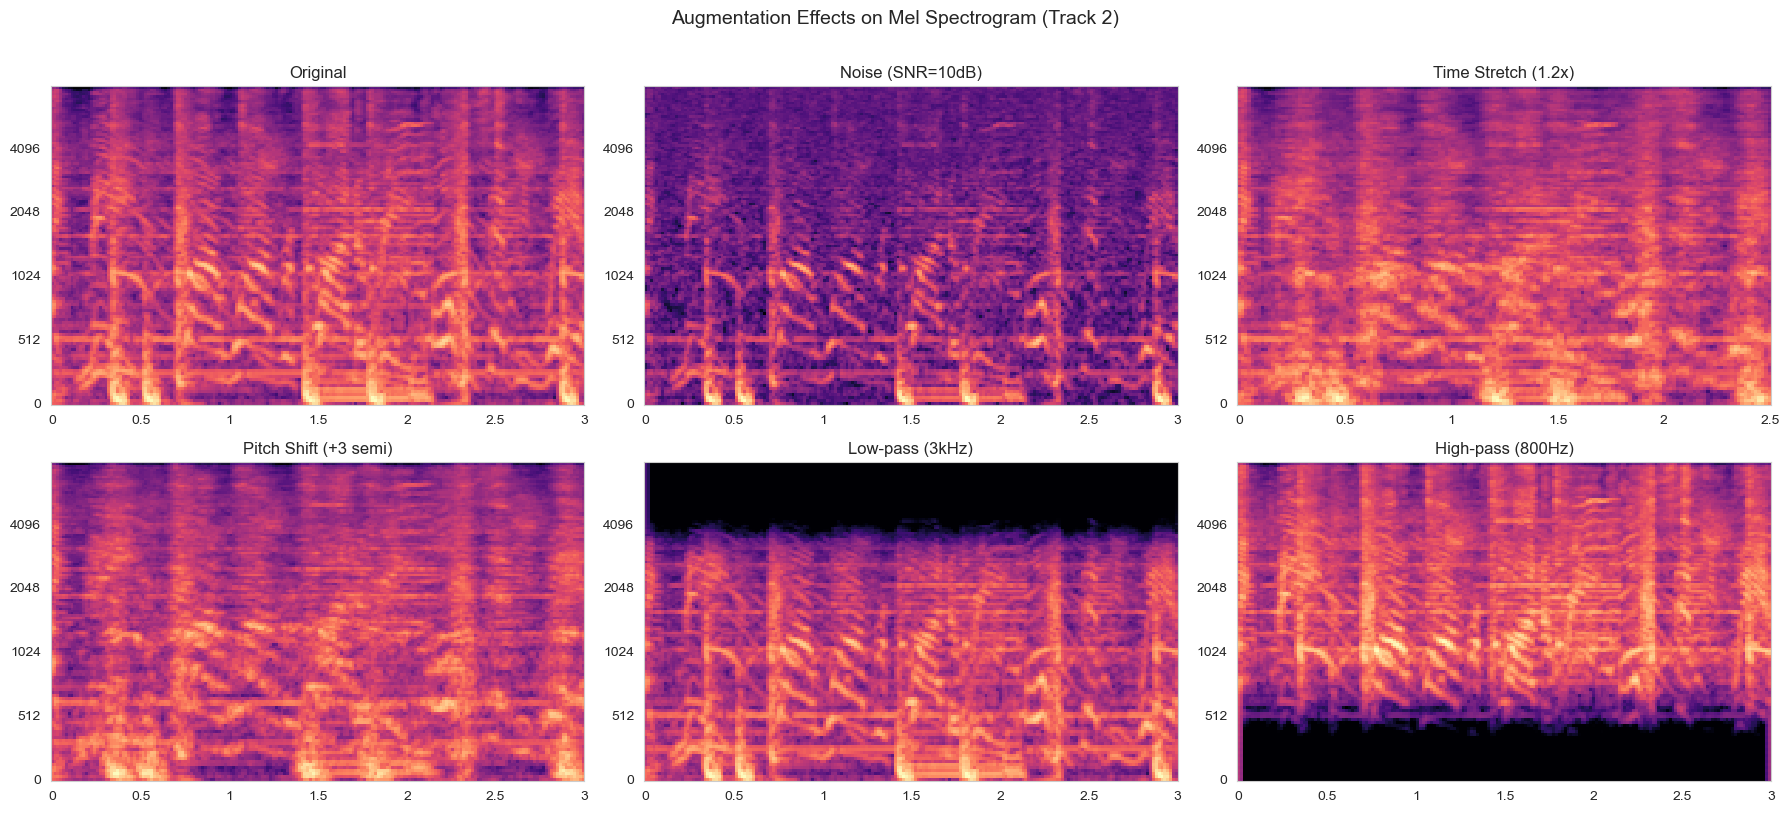

Audio playback for each augmentation:

--- Original ---



--- Noise (SNR=10dB) ---



--- Time Stretch (1.2x) ---



--- Pitch Shift (+3 semi) ---



--- Low-pass (3kHz) ---



--- High-pass (800Hz) ---


In [16]:
# ---------------------------------------------------------------------------
# Visualize the effect of each augmentation on a single track's spectrogram.
# This is the kind of distortion our contrastive model must be invariant to.
# ---------------------------------------------------------------------------
if AUDIO_DIR.exists():
    # Pick a single track for augmentation demonstration.
    demo_id = tracks_small.index[0]
    demo_path = get_audio_path(AUDIO_DIR, demo_id)
    y_orig = load_audio(demo_path)

    if y_orig is not None:
        # Take a 3-second segment from the middle of the track.
        mid = len(y_orig) // 2
        y_seg = y_orig[mid - SEGMENT_SAMPLES // 2 : mid + SEGMENT_SAMPLES // 2]

        augmentations = {
            "Original": y_seg,
            "Noise (SNR=10dB)": augment_add_noise(y_seg, snr_db=10),
            "Time Stretch (1.2x)": augment_time_stretch(y_seg, rate=1.2),
            "Pitch Shift (+3 semi)": augment_pitch_shift(y_seg, n_steps=3),
            "Low-pass (3kHz)": augment_lowpass(y_seg, cutoff_hz=3000),
            "High-pass (800Hz)": augment_highpass(y_seg, cutoff_hz=800),
        }

        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        axes = axes.flatten()

        for i, (name, y_aug) in enumerate(augmentations.items()):
            S_dB = compute_mel_spectrogram(y_aug)
            librosa.display.specshow(
                S_dB, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                x_axis="time", y_axis="mel", ax=axes[i], cmap="magma"
            )
            axes[i].set_title(name, fontsize=12)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        fig.suptitle(
            f"Augmentation Effects on Mel Spectrogram (Track {demo_id})",
            fontsize=14, y=1.01
        )
        plt.tight_layout()
        plt.show()

        # Also let you listen to each augmented version.
        print("Audio playback for each augmentation:")
        for name, y_aug in augmentations.items():
            print(f"\n--- {name} ---")
            ipd.display(ipd.Audio(data=y_aug, rate=SAMPLE_RATE))
else:
    print("Audio not downloaded — skipping augmentation demo.")

## 6. Contrastive Pair Construction

In the NAFP framework, a training batch consists of **(anchor, positive)**
pairs where the anchor is a clean segment and the positive is an augmented
version of the same segment. Negative pairs come from other tracks in the
same mini-batch (in-batch negatives via inner-product search).

Below we implement a `ContrastivePairDataset` that:
1. Randomly samples a segment from a track.
2. Applies a random composition of augmentations to create the positive.
3. Returns both as mel spectrograms, ready for transformer input.

In [13]:
from torch.utils.data import Dataset, DataLoader


class ContrastivePairDataset(Dataset):
    """
    A PyTorch Dataset that yields (anchor_spectrogram, positive_spectrogram)
    pairs for contrastive learning-based audio fingerprinting.

    For each sample, a random segment is extracted from a track. The anchor
    is the clean mel spectrogram; the positive is the same segment after a
    random chain of augmentations (noise, time stretch, pitch shift, filtering).

    Attributes:
        audio_dir:         Root directory of FMA audio files.
        track_ids:         List of integer track IDs to sample from.
        sr:                Target sample rate.
        segment_duration:  Duration of each audio segment in seconds.
        n_fft:             FFT window size for mel spectrogram.
        hop_length:        Hop length for mel spectrogram.
        n_mels:            Number of mel bands.
    """

    def __init__(
        self,
        audio_dir: Path,
        track_ids: list[int],
        sr: int = SAMPLE_RATE,
        segment_duration: float = SEGMENT_DURATION,
        n_fft: int = N_FFT,
        hop_length: int = HOP_LENGTH,
        n_mels: int = N_MELS,
    ):
        self.audio_dir = audio_dir
        self.track_ids = track_ids
        self.sr = sr
        self.segment_samples = int(segment_duration * sr)
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels

    def __len__(self) -> int:
        return len(self.track_ids)

    def _extract_random_segment(self, y: np.ndarray) -> np.ndarray:
        """
        Extract a random contiguous segment of self.segment_samples length.
        If the audio is shorter than the segment length, it is zero-padded.

        Args:
            y: Full-length 1-D audio waveform.

        Returns:
            1-D numpy array of exactly self.segment_samples length.
        """
        if len(y) <= self.segment_samples:
            # Zero-pad short tracks.
            padded = np.zeros(self.segment_samples, dtype=np.float32)
            padded[: len(y)] = y
            return padded

        max_start = len(y) - self.segment_samples
        start = np.random.randint(0, max_start)
        return y[start : start + self.segment_samples]

    def _apply_random_augmentations(self, y: np.ndarray) -> np.ndarray:
        """
        Apply a randomly composed chain of augmentations. Each augmentation
        is applied with 50% probability and random parameters within
        realistic ranges.

        Args:
            y: 1-D audio segment.

        Returns:
            Augmented 1-D audio segment.
        """
        # Noise injection: SNR between 5 and 30 dB.
        if np.random.random() < 0.5:
            snr = np.random.uniform(5, 30)
            y = augment_add_noise(y, snr_db=snr)

        # Time stretching: rate between 0.8x and 1.25x.
        if np.random.random() < 0.5:
            rate = np.random.uniform(0.8, 1.25)
            y = augment_time_stretch(y, rate=rate)
            # Re-trim or pad to segment length after stretching.
            if len(y) > self.segment_samples:
                y = y[: self.segment_samples]
            elif len(y) < self.segment_samples:
                pad = np.zeros(self.segment_samples, dtype=np.float32)
                pad[: len(y)] = y
                y = pad

        # Pitch shifting: between -4 and +4 semitones.
        if np.random.random() < 0.3:
            n_steps = np.random.uniform(-4, 4)
            y = augment_pitch_shift(y, sr=self.sr, n_steps=n_steps)

        # Low-pass filter: cutoff between 2kHz and 6kHz.
        if np.random.random() < 0.4:
            cutoff = np.random.uniform(2000, 6000)
            y = augment_lowpass(y, sr=self.sr, cutoff_hz=cutoff)

        # High-pass filter: cutoff between 100Hz and 1kHz.
        if np.random.random() < 0.3:
            cutoff = np.random.uniform(100, 1000)
            y = augment_highpass(y, sr=self.sr, cutoff_hz=cutoff)

        # Random gain: between -8dB and +8dB.
        if np.random.random() < 0.5:
            y = augment_random_gain(y, min_db=-8, max_db=8)

        return y

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Load a track, extract a random segment, compute the anchor spectrogram
        and an augmented positive spectrogram.

        Args:
            idx: Index into self.track_ids.

        Returns:
            Tuple of (anchor, positive) tensors, each of shape
            (1, n_mels, time_frames).
        """
        track_id = self.track_ids[idx]
        fpath = get_audio_path(self.audio_dir, track_id)

        y = load_audio(fpath, sr=self.sr)
        if y is None:
            # Fallback: return zeros if the file can't be loaded.
            n_frames = self.segment_samples // self.hop_length + 1
            zeros = torch.zeros(1, self.n_mels, n_frames)
            return zeros, zeros

        # Extract a random segment.
        segment = self._extract_random_segment(y)

        # Anchor: clean mel spectrogram.
        anchor_spec = compute_mel_spectrogram(
            segment, sr=self.sr,
            n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )

        # Positive: augmented mel spectrogram.
        augmented = self._apply_random_augmentations(segment.copy())
        positive_spec = compute_mel_spectrogram(
            augmented, sr=self.sr,
            n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels
        )

        # Convert to tensors with a channel dimension (1, n_mels, T).
        anchor_t = torch.from_numpy(anchor_spec).unsqueeze(0).float()
        positive_t = torch.from_numpy(positive_spec).unsqueeze(0).float()

        return anchor_t, positive_t

Training tracks available: 6400


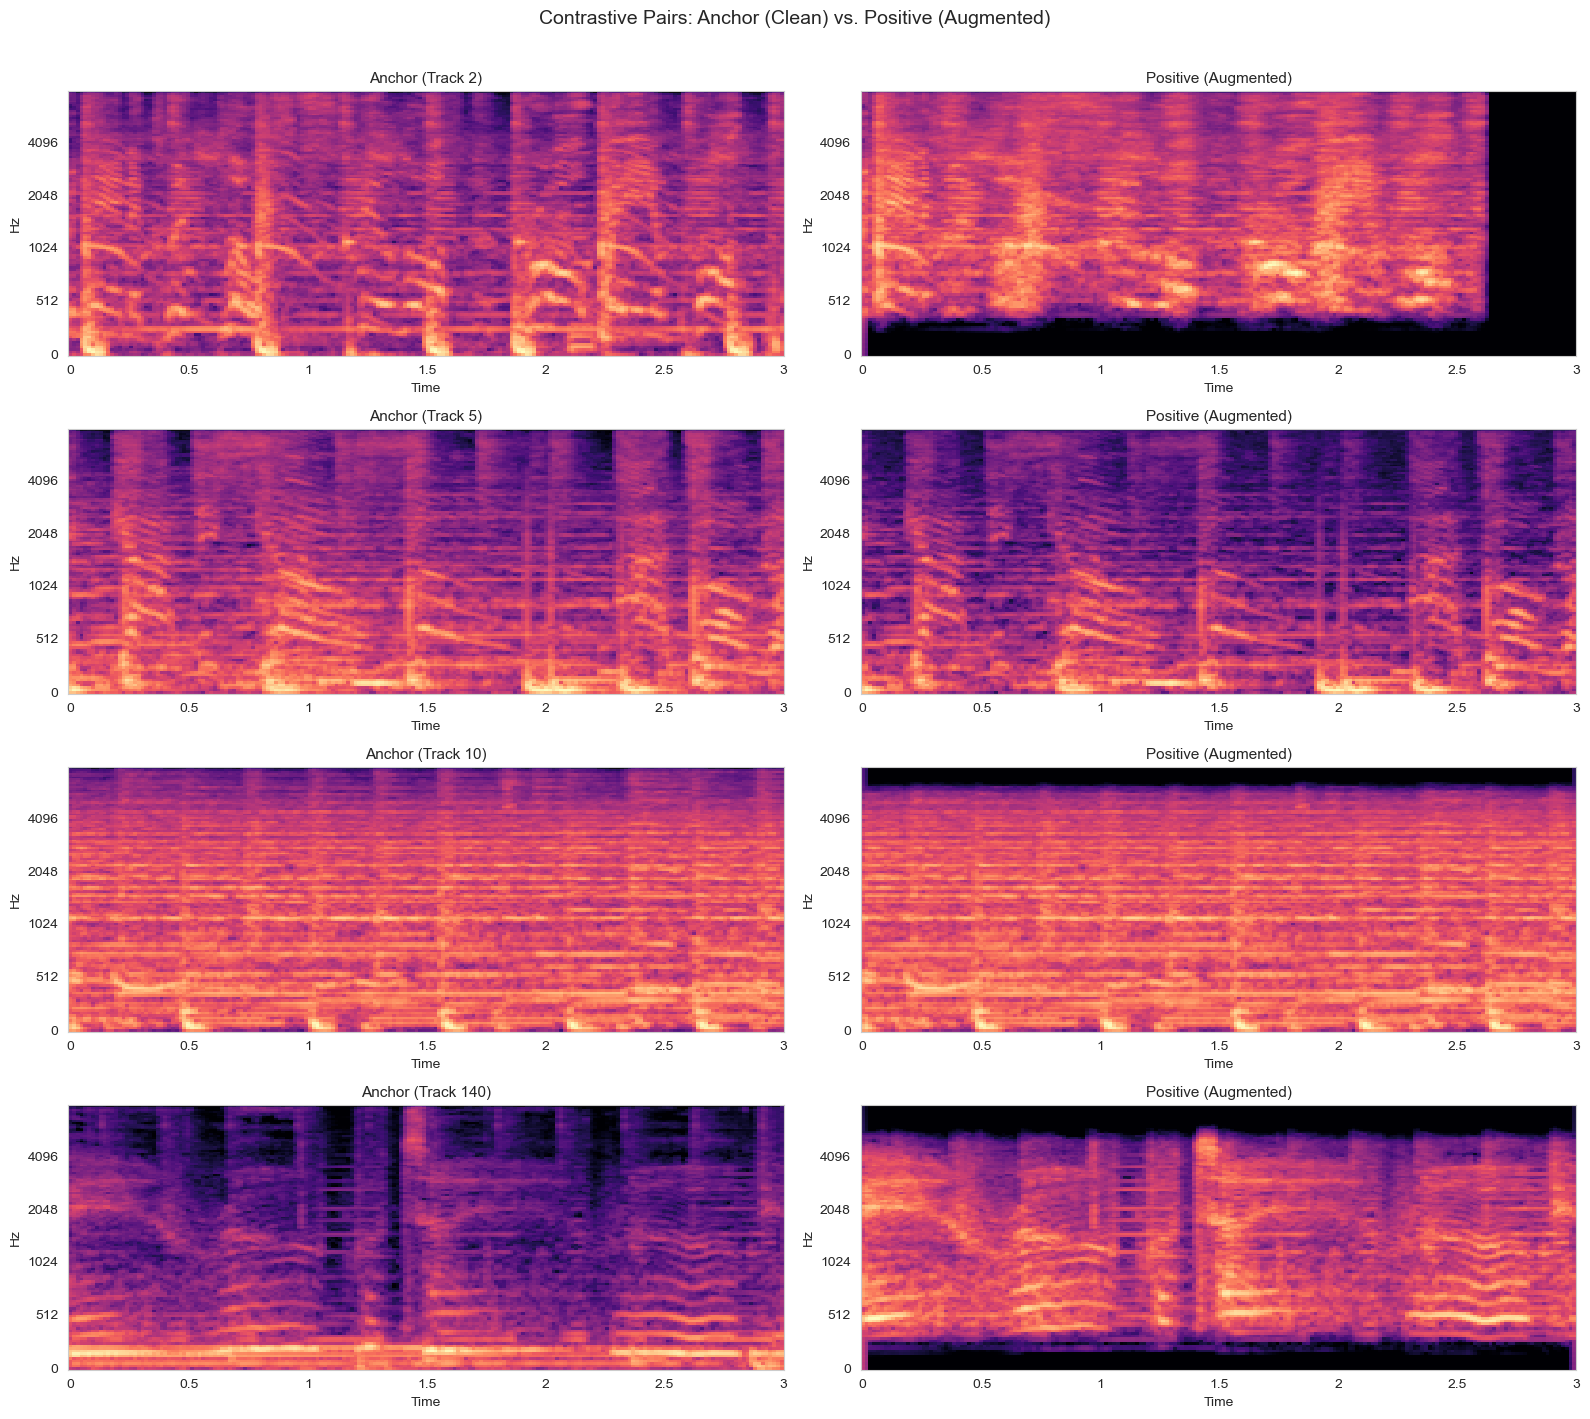


Anchor shape : torch.Size([1, 128, 188])  (channels, mel_bands, time_frames)
Positive shape: torch.Size([1, 128, 188])


In [15]:
# ---------------------------------------------------------------------------
# Demonstrate the dataset by loading a small batch and visualizing pairs.
# ---------------------------------------------------------------------------
if AUDIO_DIR.exists():
    # Use the training split of the small subset.
    train_mask = (
        (tracks["set", "subset"] <= "small")
        & (tracks["set", "split"] == "training")
    )
    train_ids = tracks[train_mask].index.tolist()
    print(f"Training tracks available: {len(train_ids)}")

    dataset = ContrastivePairDataset(
        audio_dir=AUDIO_DIR,
        track_ids=train_ids[:100],  # Use a small subset for demo speed.
    )

    # Grab 4 pairs to visualize.
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    for i in range(4):
        anchor, positive = dataset[i]

        # anchor and positive are (1, n_mels, T) tensors.
        librosa.display.specshow(
            anchor.squeeze(0).numpy(), sr=SAMPLE_RATE,
            hop_length=HOP_LENGTH, x_axis="time", y_axis="mel",
            ax=axes[i, 0], cmap="magma"
        )
        axes[i, 0].set_title(f"Anchor (Track {train_ids[i]})", fontsize=11)

        librosa.display.specshow(
            positive.squeeze(0).numpy(), sr=SAMPLE_RATE,
            hop_length=HOP_LENGTH, x_axis="time", y_axis="mel",
            ax=axes[i, 1], cmap="magma"
        )
        axes[i, 1].set_title(f"Positive (Augmented)", fontsize=11)

    fig.suptitle(
        "Contrastive Pairs: Anchor (Clean) vs. Positive (Augmented)",
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # Report tensor shapes — this is what the transformer encoder will ingest.
    a, p = dataset[0]
    print(f"\nAnchor shape : {a.shape}  (channels, mel_bands, time_frames)")
    print(f"Positive shape: {p.shape}")
else:
    print("Audio not downloaded — skipping contrastive pair demo.")

## 7. Dataset Statistics Summary

Let's compile a summary table of the key dataset statistics that will
go into our project report.

In [14]:
# ---------------------------------------------------------------------------
# Summary statistics for the report.
# ---------------------------------------------------------------------------
train_mask_full = (
    (tracks["set", "subset"] <= "small") & (tracks["set", "split"] == "training")
)
val_mask = (
    (tracks["set", "subset"] <= "small") & (tracks["set", "split"] == "validation")
)
test_mask = (
    (tracks["set", "subset"] <= "small") & (tracks["set", "split"] == "test")
)

summary = {
    "Dataset": "FMA Small",
    "Total Tracks": len(tracks_small),
    "Training Tracks": int(train_mask_full.sum()),
    "Validation Tracks": int(val_mask.sum()),
    "Test Tracks": int(test_mask.sum()),
    "Genres": len(tracks_small["track", "genre_top"].dropna().unique()),
    "Median Duration (s)": f"{durations.median():.1f}",
    "Sample Rate (target)": f"{SAMPLE_RATE} Hz",
    "Mel Bands": N_MELS,
    "FFT Window": N_FFT,
    "Hop Length": HOP_LENGTH,
    "Segment Duration (s)": SEGMENT_DURATION,
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Property", "Value"])
print(summary_df.to_string(index=False))

            Property     Value
             Dataset FMA Small
        Total Tracks      8000
     Training Tracks      6400
   Validation Tracks       800
         Test Tracks       800
              Genres         8
 Median Duration (s)     215.0
Sample Rate (target)  16000 Hz
           Mel Bands       128
          FFT Window      1024
          Hop Length       256
Segment Duration (s)       3.0


## 8. Next Steps

With the data exploration and preprocessing pipeline established, the
remaining work for the project includes:

1. **Transformer Encoder Architecture**: Implement a Vision Transformer
   (ViT)-style encoder that treats mel spectrogram patches as tokens.
   Alternatively, explore using a pre-trained music foundation model
   backbone (MuQ or MERT) as demonstrated in Singh et al. (2025).

2. **Contrastive Training Loop**: Implement the NT-Xent (normalized
   temperature-scaled cross-entropy) loss from the NAFP paper, using
   in-batch negatives with maximum inner-product search (MIPS).

3. **Fingerprint Index & Retrieval**: After training, extract embeddings
   for all reference tracks and build a FAISS index for approximate
   nearest-neighbor search.

4. **Evaluation**: Measure top-1/top-10 hit rates under clean and
   degraded query conditions (noise, compression, recording-through-
   device) following the protocol from the 2507.06070 paper.

5. **Baseline Comparison**: Compare against a CNN-based fingerprinter
   and, if feasible, the Chromaprint/Shazam-style spectral peak approach.